#1 Using Bayes’ theorem for statistical inference

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

def likelihood(theta):
    return comb(10, 7) * (theta**7) * ((1 - theta)**3)

def prior(theta):
    return np.where((theta >= 0.5) & (theta <= 1.0), 2.0, 0.0)

def posterior(theta):
    marginal_likelihood = 227 / 1408
    return (likelihood(theta) * prior(theta)) / marginal_likelihood

Exercise 1: Estimate the posterior density for specific values of θ

We will calculate the posterior density for θ∈{0.75,0.25,1}.



In [2]:
theta_values = [0.75, 0.25, 1.0]

for t in theta_values:
    # Converting to a numpy array temporarily so our vectorized 'prior' function handles it correctly
    val = posterior(np.array(t))
    print(f"Posterior density for theta = {t}: {val:.4f}")

Posterior density for theta = 0.75: 3.1048
Posterior density for theta = 0.25: 0.0000
Posterior density for theta = 1.0: 0.0000


Exercise 2: Graph the posterior distribution of θ

We'll create an array of evenly spaced values between 0 and 1 to plot the posterior distribution curve.

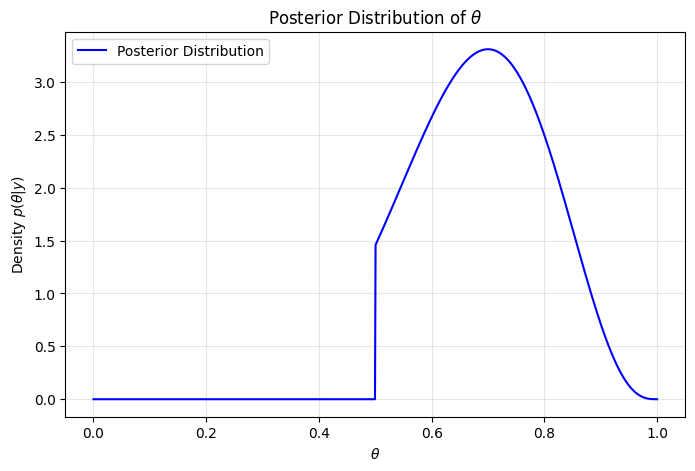

In [3]:
theta_space = np.linspace(0, 1, 1000)
posterior_space = posterior(theta_space)

plt.figure(figsize=(8, 5))
plt.plot(theta_space, posterior_space, label='Posterior Distribution', color='blue')
plt.xlabel('$\\theta$')
plt.ylabel('Density $p(\\theta|y)$')
plt.title('Posterior Distribution of $\\theta$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Exercise 3: What value of θ has the maximum posterior density?

We can find this by checking the maximum value in our calculated arrays. Analytically, since the prior is uniform in the valid range, the maximum of the posterior will be the maximum of the likelihood, which occurs at y/n=7/10=0.7.

In [4]:
max_index = np.argmax(posterior_space)
optimal_theta = theta_space[max_index]

print(f"The value of theta with the maximum posterior density is approximately: {optimal_theta:.3f}")

The value of theta with the maximum posterior density is approximately: 0.700


Exercise 4: Compare the graphs of the likelihood function, the prior distribution, and the posterior distribution.

We will plot all three functions on the same axes for comparison.

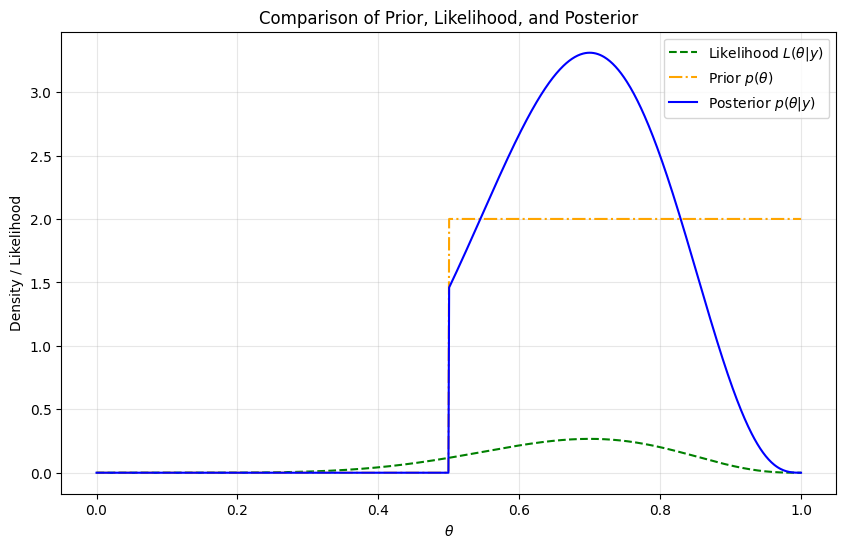

In [5]:
likelihood_space = likelihood(theta_space)
prior_space = prior(theta_space)

plt.figure(figsize=(10, 6))

plt.plot(theta_space, likelihood_space, label='Likelihood $L(\\theta|y)$', color='green', linestyle='--')
plt.plot(theta_space, prior_space, label='Prior $p(\\theta)$', color='orange', linestyle='-.')
plt.plot(theta_space, posterior_space, label='Posterior $p(\\theta|y)$', color='blue')

plt.xlabel('$\\theta$')
plt.ylabel('Density / Likelihood')
plt.title('Comparison of Prior, Likelihood, and Posterior')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#2 Model building in the Bayesian framework

Question 1: Graph of unnormalized posterior distribution of mu.

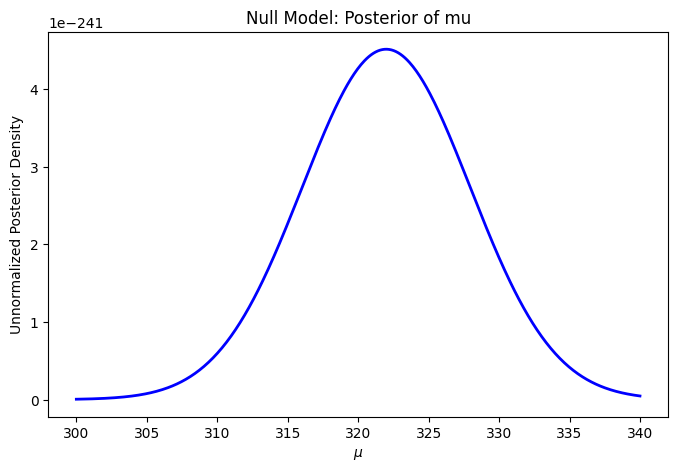

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, truncnorm, gaussian_kde

dat = pd.read_csv("recognition.csv")
Tw = dat['Tw'].values
Tnw = dat['Tnw'].values

def unnorm_post_mu_null(mu_val):
    lik_w = np.prod(norm.pdf(Tw, loc=mu_val, scale=60))
    lik_nw = np.prod(norm.pdf(Tnw, loc=mu_val, scale=60))
    prior_mu = norm.pdf(mu_val, loc=300, scale=50)
    return lik_w * lik_nw * prior_mu

mu_seq = np.linspace(300, 340, 500)
post_mu_null_vals = [unnorm_post_mu_null(m) for m in mu_seq]

plt.figure(figsize=(8, 5))
plt.plot(mu_seq, post_mu_null_vals, color='blue', lw=2)
plt.xlabel(r'$\mu$')
plt.ylabel('Unnormalized Posterior Density')
plt.title('Null Model: Posterior of mu')
plt.show()

Question 2: Prior predictions from the lexical-access model.

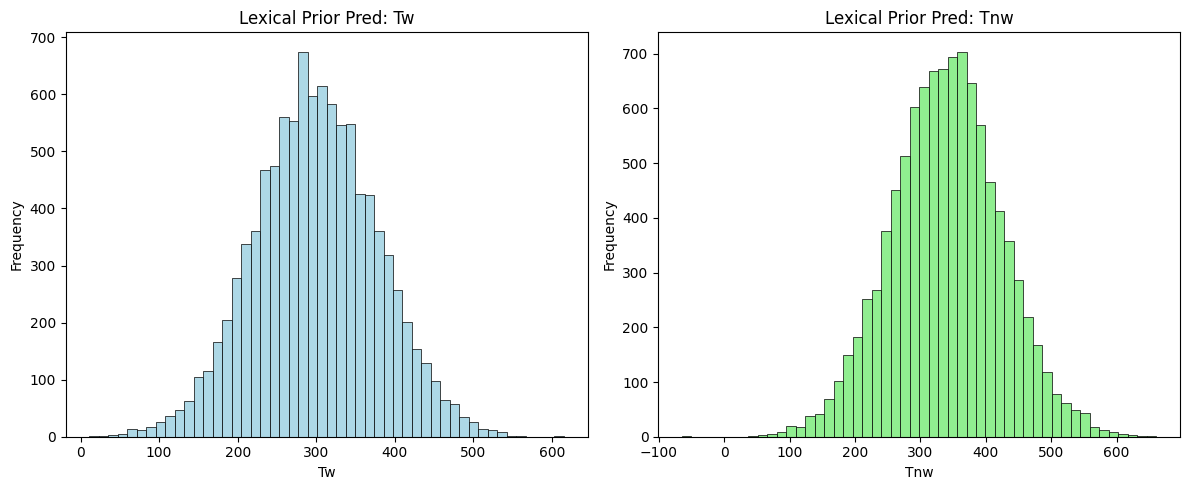

In [11]:
np.random.seed(42)
n_sim = 10000
mu_prior = norm.rvs(loc=300, scale=50, size=n_sim)

mean, sd = 0, 50
a_std = (0 - mean) / sd
b_std = (np.inf - mean) / sd
delta_prior = truncnorm.rvs(a_std, b_std, loc=mean, scale=sd, size=n_sim)

Tw_pred_lex = norm.rvs(loc=mu_prior, scale=60, size=n_sim)
Tnw_pred_lex = norm.rvs(loc=mu_prior + delta_prior, scale=60, size=n_sim)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(Tw_pred_lex, bins=50, color='lightblue', edgecolor='black', linewidth=0.5)
axes[0].set_title('Lexical Prior Pred: Tw')
axes[0].set_xlabel('Tw')
axes[0].set_ylabel('Frequency')

axes[1].hist(Tnw_pred_lex, bins=50, color='lightgreen', edgecolor='black', linewidth=0.5)
axes[1].set_title('Lexical Prior Pred: Tnw')
axes[1].set_xlabel('Tnw')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Question 3: Compare prior predictions of null vs lexical models.

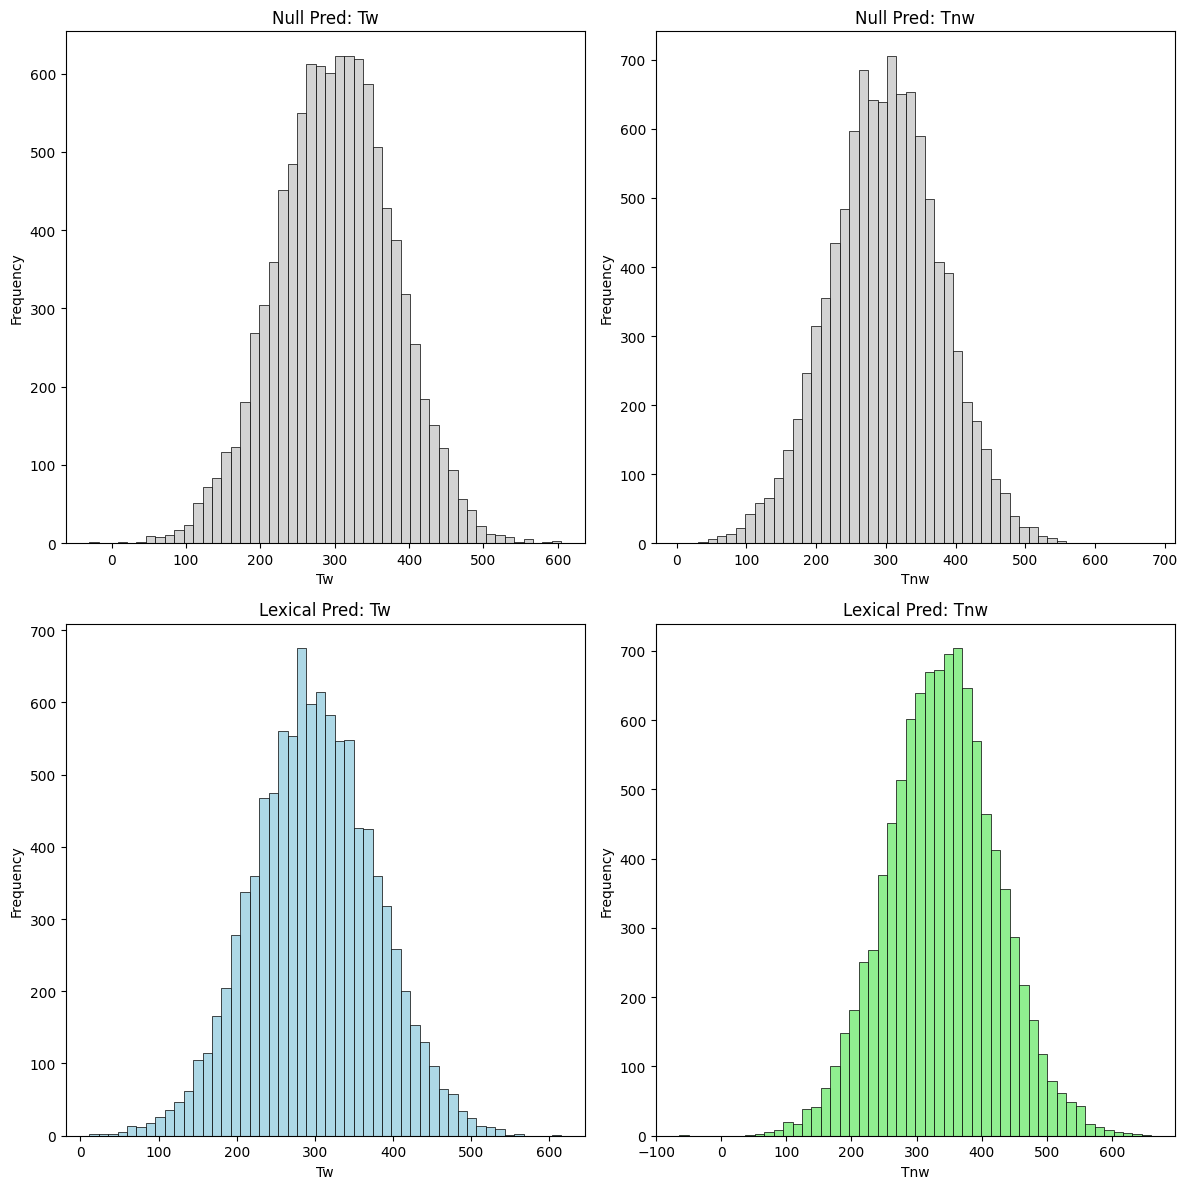

In [12]:
Tw_pred_null = norm.rvs(loc=mu_prior, scale=60, size=n_sim)
Tnw_pred_null = norm.rvs(loc=mu_prior, scale=60, size=n_sim)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].hist(Tw_pred_null, bins=50, color='lightgrey', edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Null Pred: Tw')
axes[0, 0].set_xlabel('Tw')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(Tnw_pred_null, bins=50, color='lightgrey', edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Null Pred: Tnw')
axes[0, 1].set_xlabel('Tnw')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(Tw_pred_lex, bins=50, color='lightblue', edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Lexical Pred: Tw')
axes[1, 0].set_xlabel('Tw')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(Tnw_pred_lex, bins=50, color='lightgreen', edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Lexical Pred: Tnw')
axes[1, 1].set_xlabel('Tnw')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Question 4: Compare prior predictions against observed data.
Conclusion: The lexical model allows a small slight systematic shift between Tw and Tnw, which matches the observed pattern; the null model cannot.

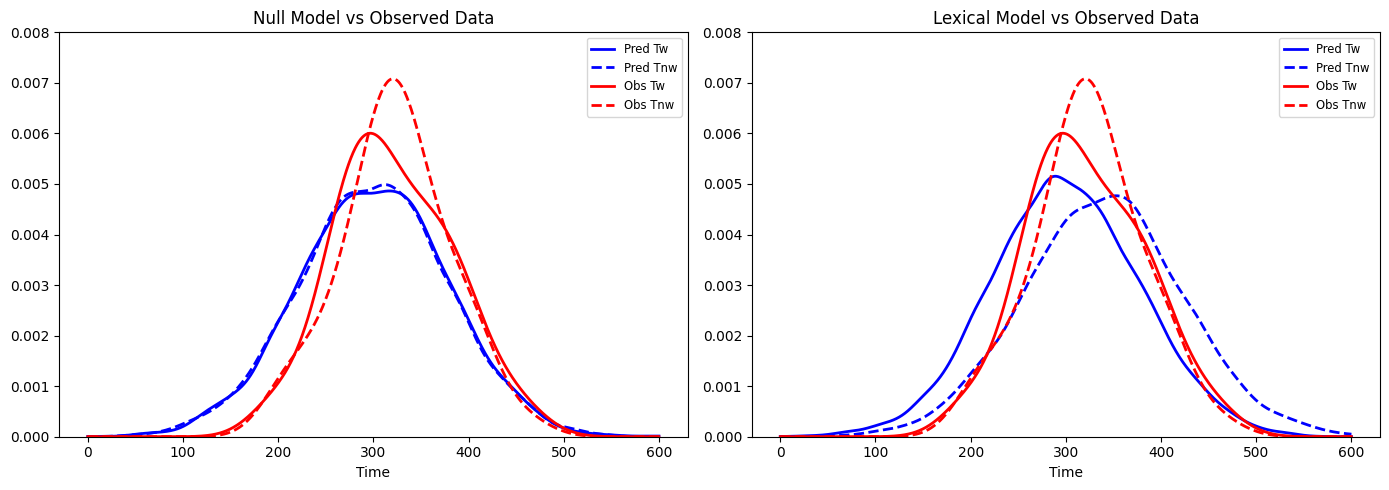

In [13]:
x_eval = np.linspace(0, 600, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Null Model vs Observed Data
axes[0].plot(x_eval, gaussian_kde(Tw_pred_null)(x_eval), color='blue', lw=2, label='Pred Tw')
axes[0].plot(x_eval, gaussian_kde(Tnw_pred_null)(x_eval), color='blue', lw=2, linestyle='--', label='Pred Tnw')
axes[0].plot(x_eval, gaussian_kde(Tw)(x_eval), color='red', lw=2, label='Obs Tw')
axes[0].plot(x_eval, gaussian_kde(Tnw)(x_eval), color='red', lw=2, linestyle='--', label='Obs Tnw')
axes[0].set_title('Null Model vs Observed Data')
axes[0].set_xlabel('Time')
axes[0].set_ylim(0, 0.008)
axes[0].legend(loc='upper right', fontsize='small')

# Lexical Model vs Observed Data
axes[1].plot(x_eval, gaussian_kde(Tw_pred_lex)(x_eval), color='blue', lw=2, label='Pred Tw')
axes[1].plot(x_eval, gaussian_kde(Tnw_pred_lex)(x_eval), color='blue', lw=2, linestyle='--', label='Pred Tnw')
axes[1].plot(x_eval, gaussian_kde(Tw)(x_eval), color='red', lw=2, label='Obs Tw')
axes[1].plot(x_eval, gaussian_kde(Tnw)(x_eval), color='red', lw=2, linestyle='--', label='Obs Tnw')
axes[1].set_title('Lexical Model vs Observed Data')
axes[1].set_xlabel('Time')
axes[1].set_ylim(0, 0.008)
axes[1].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

Question 5: Integrating the joint posterior

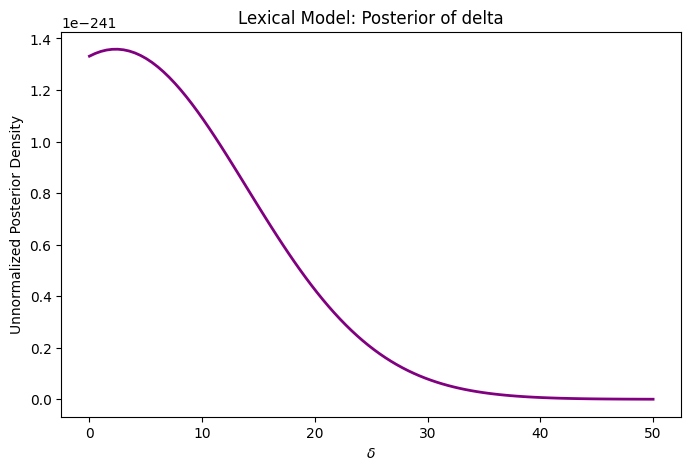

In [14]:
def unnorm_post_delta(delta_val):
    mu_grid = np.linspace(280, 360, 100) # Grid of mu values
    sum_marginal = 0

    for m in mu_grid:
        lik_w = np.prod(norm.pdf(Tw, loc=m, scale=60))
        lik_nw = np.prod(norm.pdf(Tnw, loc=m + delta_val, scale=60))
        prior_m = norm.pdf(m, loc=300, scale=50)

        # Integrate over mu
        sum_marginal += (lik_w * lik_nw * prior_m)

    prior_d = truncnorm.pdf(delta_val, a_std, b_std, loc=mean, scale=sd)
    return sum_marginal * prior_d

delta_seq = np.linspace(0, 50, 100)
post_delta_vals = [unnorm_post_delta(d) for d in delta_seq]

plt.figure(figsize=(8, 5))
plt.plot(delta_seq, post_delta_vals, color='purple', lw=2)
plt.xlabel(r'$\delta$')
plt.ylabel('Unnormalized Posterior Density')
plt.title('Lexical Model: Posterior of delta')
plt.show()